# 53-TET Chord Tokenizer for Harmonic Progression Prediction

## Adapting ChromaFlow for 53-EDO Microtonal Harmony

This notebook designs a tokenizer for the 53-TET MPE MIDI files, preparing data
to train a transformer-based chord progression predictor — analogous to
**ChromaFlow** (12-TET) but extended to microtonal harmony.

### Key Differences from 12-TET ChromaFlow:
| Aspect | ChromaFlow (12-TET) | ANIMA (53-TET) |
|--------|-------------------|----------------|
| Pitch resolution | 12 semitones/octave | 53 steps/octave |
| Pitch encoding | MIDI note (int) | MIDI note + pitch bend (float) |
| Voicing array | 8 × integer MIDI notes | 8 × (note, bend) pairs = 16 values |
| Augmentation | 12 key transpositions | 5 diatonic patterns × 53 rotations |
| Chord vocabulary | ~200 chord types | Same roots/natures + pattern token |
| Token sequence | style + tonality + chords | style + tonality + **pattern** + chords |

### Pipeline Overview:
1. **Extract** chords from MPE53 MIDI files (note + pitch bend per voice)
2. **Tokenize** each chord: `[. duration root nature extensions pattern]`
3. **Encode voicings** as 16-element arrays: 8 × (MIDI_note, bend_semitones)
4. **Build vocabulary** and integer-map all tokens
5. **Package** into (input, target, midi_embedding) tensors for GPT training


In [2]:
import numpy as np
import json
import os
from pathlib import Path
from collections import defaultdict, Counter
from mido import MidiFile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle

# Configuration
SAMPLE_RATE = 44100
PITCH_BEND_RANGE = 2  # ±2 semitones (matches 09_data_augmentation_53edo.ipynb)
CENTS_PER_STEP = 1200 / 53  # ≈ 22.64 cents per 53-TET step
BLOCK_SIZE = 1024  # Max sequence length (same as ChromaFlow)
VOICING_DIM = 16   # 8 notes × 2 (MIDI note + bend) — extended from ChromaFlow's 8

MPE_DIR = Path('../dataset/midi_files/mpe')
MPE53_DIR = Path('../dataset/midi_files/mpe53')
REF_NOTES_PATH = Path('../53_reference_notes.json')
METADATA_DIR = Path('../dataset/metadata')

PATTERNS = sorted([p.name for p in MPE53_DIR.iterdir() if p.is_dir()])

print(f"53-TET step size: {CENTS_PER_STEP:.4f} cents")
print(f"12-TET files: {len(list(MPE_DIR.glob('*.mid')))}")
print(f"Pattern folders ({len(PATTERNS)}): {PATTERNS}")
print(f"Block size: {BLOCK_SIZE}, Voicing dim: {VOICING_DIM}")


/home/trekar/Descargas/TESIS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


53-TET step size: 22.6415 cents
12-TET files: 48062
Pattern folders (5): ['8-8-5-8-8-9-7', '8-8-6-8-8-8-7', '9-7-6-9-8-8-6', '9-8-5-9-8-9-5', '9-9-4-9-9-9-4']
Block size: 1024, Voicing dim: 16


## 1. Load 53-TET Reference Data

The reference maps each of the 423 microtonal positions to:
- A closest MIDI note (12-TET approximation)
- A pitch bend offset in semitones
- A frequency in Hz


In [3]:
# Load 53-TET reference notes
with open(REF_NOTES_PATH) as f:
    ref_data = json.load(f)

ref_notes = ref_data['notes']
print(f"Loaded {len(ref_notes)} 53-TET reference notes")
print(f"Reference range: {ref_notes[0]['reference']} to {ref_notes[-1]['reference']}")
print(f"MIDI range: {ref_notes[0]['MIDI']} to {ref_notes[-1]['MIDI']}")

# Build lookup: (midi_note, bend) -> 53-TET reference index
# And reverse: 53-TET ref -> (midi, bend, freq, name)
ref_by_index = {}
for note in ref_notes:
    ref_by_index[note['reference']] = {
        'midi': note['MIDI'],
        'bend': note['bend'],
        'freq': note['frequency'],
        'name': note['noteName']
    }

# Build reverse lookup: (midi_note) -> list of possible 53-TET refs
midi_to_refs = defaultdict(list)
for note in ref_notes:
    midi_to_refs[note['MIDI']].append(note)

# Show C4 neighborhood  
print(f"\nC4 (MIDI 60) has {len(midi_to_refs[60])} 53-TET positions:")
for n in midi_to_refs[60]:
    print(f"  ref={n['reference']:>4d}  bend={n['bend']:.4f}st  name={n['noteName']}")


Loaded 423 53-TET reference notes
Reference range: -53 to 369
MIDI range: 21 to 116

C4 (MIDI 60) has 5 53-TET positions:
  ref= 119  bend=0.0000st  name=C3
  ref= 120  bend=0.2264st  name=^C4
  ref= 121  bend=0.4528st  name=^^C4
  ref= 122  bend=0.6792st  name=vvC#4
  ref= 123  bend=0.9057st  name=vC#4


## 2. MIDI Extraction Functions

Extract notes with pitch bend from MPE MIDI files.
Each note becomes a tuple: `(onset_time, offset_time, midi_note, bend_semitones, velocity, channel)`


In [4]:
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def note_name_from_midi(midi_note, bend=0.0):
    """Human-readable note name with microtonal offset."""
    base = NOTE_NAMES[midi_note % 12]
    octave = midi_note // 12 - 1
    if abs(bend) > 0.001:
        return f"{base}{octave}{bend:+.2f}"
    return f"{base}{octave}"

def extract_mpe_notes(midi_path):
    """Extract all notes from an MPE MIDI file with per-note pitch bend.
    
    Returns list of dicts with keys:
        onset, offset, midi_note, bend, velocity, channel
    """
    mid = MidiFile(str(midi_path))
    notes = []
    active = {}       # (channel, note) -> (onset_time, bend_at_onset, velocity)
    bend = [0.0] * 16 # Current pitch bend per channel
    time = 0.0
    
    for msg in mid:
        time += msg.time
        
        if msg.type == 'pitchwheel':
            bend[msg.channel] = (msg.pitch / 8192) * PITCH_BEND_RANGE
            
        elif msg.type == 'note_on' and msg.velocity > 0:
            active[(msg.channel, msg.note)] = (time, bend[msg.channel], msg.velocity)
            
        elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
            key = (msg.channel, msg.note)
            if key in active:
                onset, b, vel = active.pop(key)
                notes.append({
                    'onset': onset,
                    'offset': time,
                    'midi_note': msg.note,
                    'bend': b,
                    'velocity': vel,
                    'channel': msg.channel
                })
    
    return sorted(notes, key=lambda x: (x['onset'], x['midi_note']))

def group_into_chords(notes, tolerance=0.05):
    """Group notes by simultaneous onset into chords.
    
    Returns list of chords, each chord is a list of note dicts.
    """
    if not notes:
        return []
    
    chords = []
    current_chord = [notes[0]]
    
    for note in notes[1:]:
        if note['onset'] - current_chord[0]['onset'] < tolerance:
            current_chord.append(note)
        else:
            chords.append(current_chord)
            current_chord = [note]
    chords.append(current_chord)
    
    return chords

# Test on a sample file
sample_pattern = PATTERNS[0]
sample_files = list((MPE53_DIR / sample_pattern).glob('*.mid'))
if sample_files:
    sample = sample_files[0]
    notes = extract_mpe_notes(sample)
    chords = group_into_chords(notes)
    
    print(f"File: {sample.name}")
    print(f"Total notes: {len(notes)}")
    print(f"Total chords: {len(chords)}")
    print(f"\nFirst 5 chords:")
    for i, chord in enumerate(chords[:5]):
        dur = chord[0]['offset'] - chord[0]['onset']
        note_strs = [f"{note_name_from_midi(n['midi_note'], n['bend'])}" for n in chord]
        print(f"  [{i}] t={chord[0]['onset']:.2f}s dur={dur:.2f}s: {' '.join(note_strs)}")


File: 53TET_37931_Fato Consumado 1_B_major.mid
Total notes: 276
Total chords: 72

First 5 chords:
  [0] t=0.00s dur=2.00s: B2-0.58 D#3-0.28 F#3-0.34 A#3-0.72
  [1] t=2.00s dur=2.00s: G#2-0.53 D#3-0.28 F#3-0.34 C4
  [2] t=4.00s dur=2.00s: C#3-0.09 E3-0.38 G#3-0.53
  [3] t=6.00s dur=2.00s: F#3-0.34 A#3-0.72 C#4-0.09 E4-0.38
  [4] t=8.00s dur=2.00s: B2-0.58 A#3-0.72 C#4-0.09 D#4-0.28


## 3. 53-TET Tokenization Strategy

### Token Design for Microtonal Chords

Unlike ChromaFlow which uses symbolic chord names (e.g., `Cmaj7`), our 53-TET data
comes from MIDI — we need to **reverse-engineer** chord identity from pitch content.

**Strategy:** Match each note's `(midi_note, bend)` to the closest 53-TET reference,
then derive the chord's **root** (in 53-TET) and **interval structure** (quality).

### Token Vocabulary:
```
Special:     <start> <end> <pad> .
Structural:  | || |: :| b|| e||
Pattern:     <pattern> 8-8-5-8-8-9-7 8-8-6-8-8-8-7 ...
Duration:    0.5 1.0 1.5 2.0 3.0 4.0 ...
Root:        C C# D D# E F F# G G# A A# B (12-TET root names)
Micro:       +0 +1 +2 +3 +4 (microtonal offset from nearest 12-TET in 53-TET steps)
Quality:     maj min dom7 maj7 m7 dim aug sus ...  
Extensions:  add9 add11 add13 b5 #5 b9 #9 #11 b13 ...
Style:       Jazz Pop Bossa Blues ...
Tonality:    (free-form key signature string)
```

The **micro offset token** (+0 to +4) captures the 53-TET deviation of the root
from standard 12-TET, enabling the model to learn pattern-specific tuning.


In [5]:
def find_closest_53ref(midi_note, bend):
    """Find the closest 53-TET reference for a (midi_note, bend) pair.
    
    Returns the reference index and the matching entry.
    """
    candidates = midi_to_refs.get(midi_note, [])
    if not candidates:
        # Fallback: search all refs
        best = min(ref_notes, key=lambda r: abs(r['MIDI'] - midi_note) + abs(r['bend'] - abs(bend)))
        return best['reference'], best
    
    # Find closest by bend value
    best = min(candidates, key=lambda r: abs(r['bend'] - abs(bend)))
    
    # Handle negative bends (bend below the MIDI note)
    if bend < -0.001:
        # The note is bent DOWN — look at refs for midi_note - 1
        lower_candidates = midi_to_refs.get(midi_note - 1, [])
        if lower_candidates:
            # We want the ref that, when bent up from midi_note-1, matches
            effective_bend = 1.0 + bend  # e.g., bend=-0.3 -> effective=0.7 semitones above midi-1
            if effective_bend > 0:
                lower_best = min(lower_candidates, key=lambda r: abs(r['bend'] - effective_bend))
                if abs(lower_best['bend'] - effective_bend) < abs(best['bend'] - abs(bend)):
                    return lower_best['reference'], lower_best
    
    return best['reference'], best

def chord_to_53tet_intervals(chord_notes):
    """Convert a chord (list of note dicts) to 53-TET interval structure.
    
    Returns:
        root_ref: 53-TET reference of the lowest note (root)
        intervals: sorted list of intervals from root in 53-TET steps
        root_midi: MIDI note of root
        root_bend: bend of root
    """
    if not chord_notes:
        return None, [], 0, 0.0
    
    # Sort by pitch (midi_note + bend)
    sorted_notes = sorted(chord_notes, key=lambda n: n['midi_note'] + n['bend'])
    
    # Get 53-TET reference for each note
    refs = []
    for note in sorted_notes:
        ref_idx, ref_entry = find_closest_53ref(note['midi_note'], note['bend'])
        refs.append(ref_idx)
    
    # Root is the lowest note
    root_ref = refs[0]
    root_note = sorted_notes[0]
    
    # Calculate intervals from root (in 53-TET steps)
    intervals = sorted(set((r - root_ref) % 53 for r in refs))
    
    return root_ref, intervals, root_note['midi_note'], root_note['bend']

# Interval-to-quality mapping in 53-TET steps
# Reference: 53-TET interval sizes
#   P1=0, m2=4-5, M2=8-9, m3=13-14, M3=17, P4=22, tritone=26-27,
#   P5=31, m6=35-36, M6=39-40, m7=44, M7=48, P8=53
QUALITY_MAP_53 = {
    (0,):                               'power1',  # single note
    (0, 17, 31):                        'maj',
    (0, 14, 31):                        'min',
    (0, 17, 31, 44):                    'dom7',
    (0, 17, 31, 48):                    'maj7',
    (0, 14, 31, 44):                    'm7',
    (0, 14, 31, 48):                    'm_maj7',
    (0, 14, 27):                        'dim',
    (0, 14, 27, 40):                    'o7',
    (0, 14, 27, 44):                    'hdim7',  # half-diminished
    (0, 17, 35):                        'aug',
    (0, 22, 31):                        'sus4',
    (0, 9, 31):                         'sus2',
    (0, 17, 31, 44, 62):                'dom9',
    (0, 14, 31, 44, 62):                'm9',
    (0, 17, 31, 48, 62):                'maj9',
    (0, 17, 31, 44, 62, 75):            'dom11',
    (0, 17, 31, 44, 62, 84):            'dom13',
}

def match_quality(intervals, tolerance=2):
    """Match 53-TET intervals to a chord quality with tolerance for tuning variants.
    
    Args:
        intervals: list of intervals in 53-TET steps from root
        tolerance: max deviation in 53-TET steps to consider a match
        
    Returns:
        quality: string chord quality name
        unmatched: list of intervals that didn't match any template
    """
    if len(intervals) <= 1:
        return 'power1', []
    
    best_match = None
    best_score = float('inf')
    best_unmatched = intervals[:]
    
    for template_intervals, quality in QUALITY_MAP_53.items():
        if len(template_intervals) > len(intervals) + 1:
            continue
        
        # Try to match each template interval to closest actual interval
        matched = 0
        total_error = 0
        used = set()
        
        for t_iv in template_intervals:
            best_diff = tolerance + 1
            best_idx = -1
            for j, a_iv in enumerate(intervals):
                if j not in used:
                    diff = abs(a_iv - t_iv)
                    if diff < best_diff:
                        best_diff = diff
                        best_idx = j
            if best_idx >= 0 and best_diff <= tolerance:
                matched += 1
                total_error += best_diff
                used.add(best_idx)
        
        # Score: penalize unmatched template notes, reward matched
        score = (len(template_intervals) - matched) * 10 + total_error
        
        if matched >= len(template_intervals) - 1 and score < best_score:
            best_score = score
            best_match = quality
            best_unmatched = [intervals[j] for j in range(len(intervals)) if j not in used]
    
    if best_match is None:
        # Fallback: describe by third quality
        has_major_third = any(abs(iv - 17) <= tolerance for iv in intervals)
        has_minor_third = any(abs(iv - 14) <= tolerance for iv in intervals)
        if has_major_third:
            best_match = 'maj'
        elif has_minor_third:
            best_match = 'min'
        else:
            best_match = 'unknown'
        best_unmatched = intervals[1:]  # everything except root
    
    return best_match, best_unmatched

# Test chord identification
print("Testing chord quality matching:")
test_intervals = [
    ([0, 17, 31], "Should be maj"),
    ([0, 14, 31, 44], "Should be m7"),
    ([0, 17, 31, 48], "Should be maj7"),
    ([0, 18, 31], "Should be ~maj (17+1 tolerance)"),
    ([0, 14, 27, 44], "Should be hdim7"),
]
for intervals, expected in test_intervals:
    quality, unmatched = match_quality(intervals)
    print(f"  {intervals} -> {quality} (unmatched: {unmatched}) | {expected}")


Testing chord quality matching:
  [0, 17, 31] -> power1 (unmatched: [17, 31]) | Should be maj
  [0, 14, 31, 44] -> power1 (unmatched: [14, 31, 44]) | Should be m7
  [0, 17, 31, 48] -> power1 (unmatched: [17, 31, 48]) | Should be maj7
  [0, 18, 31] -> power1 (unmatched: [18, 31]) | Should be ~maj (17+1 tolerance)
  [0, 14, 27, 44] -> power1 (unmatched: [14, 27, 44]) | Should be hdim7


## 4. Tokenizer Class

The core tokenizer converts MPE53 MIDI files into token sequences compatible
with the GPT architecture used in ChromaFlow.

### Sequence Format:
```
<start> <style> Jazz <pattern> 9-9-4-9-9-9-4 <tonality> G minor
| . 4.0 G min +0 | . 4.0 D dom7 +1 add9 | . 2.0 C maj7 +0 . 2.0 F dom7 +2
... <end> <pad> <pad> ...
```

### Voicing Encoding (16-dim):
For each chord token (`.`), we store an array of 16 values:
```
[note0, bend0, note1, bend1, ..., note7, bend7]
```
Where each (noteN, bendN) pair represents one voice of the chord.
Zero-padded for chords with fewer than 8 voices.


In [6]:
class Tokenizer53TET:
    """Tokenizer for 53-TET MPE MIDI chord progressions.
    
    Converts MIDI files to token sequences and voicing arrays,
    following the ChromaFlow architecture but extended for microtonality.
    """
    
    # Special tokens
    SPECIAL_TOKENS = ['<start>', '<end>', '<pad>', '.']
    
    # Structural tokens
    STRUCTURAL_TOKENS = ['|', '||', 'b||', 'e||', '|:', ':|']
    
    # Style tokens (from ChromaFlow)
    STYLE_TOKENS = ['<style>', 'Jazz', 'Pop', 'Bossa', 'Blues', 'Rock', 
                    'Funk', 'Samba', 'Folk', 'Reggae', 'Soul', 'RnB',
                    'Even 8ths', 'Son', 'Balad', 'Gospel', 'Afoxe']
    
    # Pattern token
    PATTERN_TOKEN = '<pattern>'
    
    # Tonality token
    TONALITY_TOKEN = '<tonality>'
    
    # Root notes (12-TET base names)
    ROOT_TOKENS = ['C', 'C#', 'Db', 'D', 'D#', 'Eb', 'E', 'F', 
                   'F#', 'Gb', 'G', 'G#', 'Ab', 'A', 'A#', 'Bb', 'B']
    
    # Microtonal offset tokens (53-TET steps from nearest 12-TET)  
    MICRO_TOKENS = ['+0', '+1', '+2', '+3', '+4', '-1', '-2', '-3', '-4']
    
    # Chord quality tokens
    QUALITY_TOKENS = ['maj', 'min', 'dom7', 'maj7', 'm7', 'm_maj7', 'dim',
                      'o7', 'hdim7', 'aug', 'sus4', 'sus2', 'dom9', 'm9',
                      'maj9', 'dom11', 'dom13', 'power1', 'unknown',
                      'maj6', 'm6', 'sus', 'sus7', 'power', 'o_maj7']
    
    # Duration tokens (quantized)
    DURATION_TOKENS = ['0.25', '0.33', '0.5', '0.67', '0.75', '1.0', 
                       '1.33', '1.5', '2.0', '2.5', '3.0', '4.0',
                       '6.0', '8.0']
    
    # Extension tokens
    EXTENSION_TOKENS = ['add2', 'add4', 'add6', 'add9', 'add11', 'add13',
                        'b5', '#5', 'b9', '#9', '#11', 'b13']
    
    QUANTIZED_DURATIONS = [0.25, 0.33, 0.5, 0.67, 0.75, 1.0, 1.33, 1.5, 
                           2.0, 2.5, 3.0, 4.0, 6.0, 8.0]
    
    def __init__(self, block_size=BLOCK_SIZE, voicing_dim=VOICING_DIM):
        self.block_size = block_size
        self.voicing_dim = voicing_dim
        self.vocab = None
        self.token_to_idx = None
        self.idx_to_token = None
        self.pad_idx = None
    
    def quantize_duration(self, duration_seconds, bpm=120):
        """Convert duration in seconds to closest quantized beat duration."""
        beats = duration_seconds * (bpm / 60.0)
        closest = min(self.QUANTIZED_DURATIONS, key=lambda x: abs(x - beats))
        return str(closest)
    
    def midi_note_to_root_and_micro(self, midi_note, bend):
        """Convert MIDI note + bend to (root_name, micro_offset) tokens.
        
        The root_name is the nearest 12-TET note name.
        The micro_offset captures the 53-TET deviation.
        """
        # Find the 53-TET reference
        ref_idx, ref_entry = find_closest_53ref(midi_note, bend)
        
        # The root in 12-TET terms
        base_pc = midi_note % 12
        root_name = NOTE_NAMES[base_pc]
        
        # Calculate micro offset: how many 53-TET steps from the 12-TET position
        # 12-TET position in 53-TET: pc * (53/12) rounded
        tet12_53step = round(base_pc * 53 / 12)
        actual_53step = ref_idx % 53
        micro_offset = actual_53step - tet12_53step
        
        # Clamp to ±4
        micro_offset = max(-4, min(4, micro_offset))
        micro_token = f"+{micro_offset}" if micro_offset >= 0 else str(micro_offset)
        
        return root_name, micro_token
    
    def chord_to_voicing_array(self, chord_notes):
        """Convert chord notes to a fixed-size voicing array.
        
        Returns array of shape (voicing_dim,) = (16,):
            [midi0, bend0, midi1, bend1, ..., midi7, bend7]
        """
        arr = np.zeros(self.voicing_dim, dtype=np.float32)
        
        # Sort by pitch
        sorted_notes = sorted(chord_notes, key=lambda n: n['midi_note'] + n['bend'])
        
        for i, note in enumerate(sorted_notes[:8]):  # Max 8 voices
            arr[i * 2] = note['midi_note']
            arr[i * 2 + 1] = note['bend']
        
        return arr
    
    def interval_to_extensions(self, unmatched_intervals):
        """Convert unmatched 53-TET intervals to extension tokens."""
        extensions = []
        for iv in unmatched_intervals:
            # Map 53-TET interval to nearest extension
            if 8 <= iv <= 10:
                extensions.append('add9' if iv > 53 else 'add2')
            elif 21 <= iv <= 23:
                extensions.append('add4')
            elif 38 <= iv <= 41:
                extensions.append('add6')
            elif 57 <= iv <= 63:
                extensions.append('add9')
            elif 70 <= iv <= 76:
                extensions.append('add11')
            elif 83 <= iv <= 86:
                extensions.append('add13')
            elif 25 <= iv <= 28:
                extensions.append('b5')
            elif 33 <= iv <= 37:
                extensions.append('#5')
        return extensions
    
    def tokenize_chord(self, chord_notes, bpm=120):
        """Tokenize a single chord into a sequence of string tokens.
        
        Returns:
            tokens: list of strings
            voicing: numpy array of shape (voicing_dim,)
        """
        if not chord_notes:
            return [], np.zeros(self.voicing_dim, dtype=np.float32)
        
        # Duration
        dur = chord_notes[0]['offset'] - chord_notes[0]['onset']
        dur_token = self.quantize_duration(dur, bpm)
        
        # Get chord structure in 53-TET
        root_ref, intervals, root_midi, root_bend = chord_to_53tet_intervals(chord_notes)
        
        # Root name and microtonal offset
        root_name, micro_token = self.midi_note_to_root_and_micro(root_midi, root_bend)
        
        # Quality
        quality, unmatched = match_quality(intervals)
        
        # Extensions from unmatched intervals
        extensions = self.interval_to_extensions(unmatched)
        
        # Build token sequence: . duration root quality micro [extensions...]
        tokens = ['.', dur_token, root_name, quality, micro_token]
        tokens.extend(extensions)
        
        # Voicing array
        voicing = self.chord_to_voicing_array(chord_notes)
        
        return tokens, voicing
    
    def tokenize_song(self, midi_path, pattern_name, style='Jazz', 
                      tonality='C major', bpm=120, beats_per_bar=4):
        """Tokenize an entire MPE53 MIDI file into a padded sequence.
        
        Returns:
            tokens: list of string tokens (length <= block_size)
            voicings: numpy array of shape (len(tokens), voicing_dim)
        """
        # Extract notes and group into chords
        notes = extract_mpe_notes(midi_path)
        chords = group_into_chords(notes)
        
        if not chords:
            return [], np.zeros((0, self.voicing_dim), dtype=np.float32)
        
        # Header tokens
        tokens = ['<start>', '<style>', style, '<pattern>', pattern_name,
                  '<tonality>', tonality]
        voicings = [np.zeros(self.voicing_dim, dtype=np.float32) for _ in tokens]
        
        # Add bar lines based on time
        current_bar_time = 0
        bar_duration = beats_per_bar * (60.0 / bpm)
        tokens.append('|')
        voicings.append(np.zeros(self.voicing_dim, dtype=np.float32))
        
        for chord in chords:
            onset = chord[0]['onset']
            
            # Insert bar lines
            while onset >= current_bar_time + bar_duration:
                current_bar_time += bar_duration
                tokens.append('|')
                voicings.append(np.zeros(self.voicing_dim, dtype=np.float32))
            
            # Tokenize chord
            chord_tokens, chord_voicing = self.tokenize_chord(chord, bpm)
            
            if chord_tokens:
                for i, tok in enumerate(chord_tokens):
                    tokens.append(tok)
                    # Only the dot token gets the full voicing
                    if i == 0:
                        voicings.append(chord_voicing)
                    else:
                        voicings.append(np.zeros(self.voicing_dim, dtype=np.float32))
            
            if len(tokens) >= self.block_size - 1:
                break
        
        # End token
        tokens.append('<end>')
        voicings.append(np.zeros(self.voicing_dim, dtype=np.float32))
        
        # Pad to block_size
        while len(tokens) < self.block_size:
            tokens.append('<pad>')
            voicings.append(np.zeros(self.voicing_dim, dtype=np.float32))
        
        # Truncate if too long
        tokens = tokens[:self.block_size]
        voicings = voicings[:self.block_size]
        
        return tokens, np.array(voicings, dtype=np.float32)

# Create tokenizer instance
tokenizer = Tokenizer53TET()
print("Tokenizer created successfully")
print(f"Block size: {tokenizer.block_size}")
print(f"Voicing dimension: {tokenizer.voicing_dim}")


Tokenizer created successfully
Block size: 1024
Voicing dimension: 16


## 5. Test Tokenization on Sample Files

Let's tokenize a few songs and examine the output to verify correctness.


In [7]:
# Tokenize a sample file from each pattern
print("Testing tokenization on sample files:\n")

for pattern in PATTERNS[:2]:  # Test first 2 patterns
    files = sorted((MPE53_DIR / pattern).glob('*.mid'))
    if not files:
        continue
    
    sample = files[0]
    tokens, voicings = tokenizer.tokenize_song(sample, pattern)
    
    # Count non-pad tokens
    non_pad = sum(1 for t in tokens if t != '<pad>')
    dot_count = sum(1 for t in tokens if t == '.')
    
    print(f"Pattern: {pattern}")
    print(f"  File: {sample.name}")
    print(f"  Non-pad tokens: {non_pad}/{len(tokens)}")
    print(f"  Chords (dots): {dot_count}")
    print(f"  Voicing shape: {voicings.shape}")
    
    # Show first 50 tokens
    print(f"  First 50 tokens: {' '.join(tokens[:50])}")
    
    # Show first 3 chord voicings (at dot positions)
    dot_indices = [i for i, t in enumerate(tokens) if t == '.'][:3]
    for di in dot_indices:
        v = voicings[di]
        note_strs = []
        for j in range(8):
            midi_n = int(v[j*2])
            bend_v = v[j*2+1]
            if midi_n > 0:
                note_strs.append(f"{note_name_from_midi(midi_n, bend_v)}")
        print(f"    Chord at pos {di}: voicing=[{', '.join(note_strs)}]")
    print()


Testing tokenization on sample files:

Pattern: 8-8-5-8-8-9-7
  File: 53TET_00000_Preciso Me Encontrar_C_minor.mid
  Non-pad tokens: 380/1024
  Chords (dots): 54
  Voicing shape: (1024, 16)
  First 50 tokens: <start> <style> Jazz <pattern> 8-8-5-8-8-9-7 <tonality> C major | . 8.0 C power1 +4 | | . 8.0 G# power1 +4 add6 | | . 4.0 A power1 +4 b5 | . 4.0 G power1 +4 | . 4.0 C power1 +4 | . 2.0 D power1 +4 b5 . 2.0
    Chord at pos 8: voicing=[C3, D#3-0.28, G3-0.43]
    Chord at pos 15: voicing=[G#2-0.53, C3, F3-0.25]
    Chord at pos 23: voicing=[A2-0.62, C3, D#3-0.28]

Pattern: 8-8-6-8-8-8-7
  File: 53TET_00000_Preciso Me Encontrar_C_minor.mid
  Non-pad tokens: 377/1024
  Chords (dots): 54
  Voicing shape: (1024, 16)
  First 50 tokens: <start> <style> Jazz <pattern> 8-8-6-8-8-8-7 <tonality> C major | . 8.0 C power1 +4 | | . 8.0 G# power1 +4 add6 | | . 4.0 A power1 +4 b5 | . 4.0 G power1 +4 | . 4.0 C power1 +4 | . 2.0 D power1 +4 b5 . 2.0
    Chord at pos 8: voicing=[C3, D#3-0.28, G3-0.21

## 6. Build Vocabulary

Scan all tokenized songs to build the complete vocabulary mapping.


In [8]:
def build_vocabulary(tokenizer_instance, max_songs_per_pattern=None, patterns=None):
    """Build vocabulary from all tokenized songs.
    
    Args:
        tokenizer_instance: Tokenizer53TET instance
        max_songs_per_pattern: limit for testing (None = all)
        patterns: list of pattern names to process (None = all)
    
    Returns:
        vocab: sorted list of unique tokens
        token_to_idx: dict mapping token -> integer index
        idx_to_token: dict mapping integer index -> token
        all_tokens: list of all tokenized songs (each a list of strings)
        all_voicings: list of all voicing arrays
    """
    if patterns is None:
        patterns = PATTERNS
    
    all_tokens_list = []
    all_voicings_list = []
    token_counter = Counter()
    
    for pattern in patterns:
        files = sorted((MPE53_DIR / pattern).glob('*.mid'))
        if max_songs_per_pattern:
            files = files[:max_songs_per_pattern]
        
        print(f"Processing pattern {pattern}: {len(files)} files")
        
        for midi_file in tqdm(files, desc=pattern):
            tokens, voicings = tokenizer_instance.tokenize_song(midi_file, pattern)
            all_tokens_list.append(tokens)
            all_voicings_list.append(voicings)
            token_counter.update(tokens)
    
    # Build vocabulary (sorted for reproducibility)
    vocab = sorted(set(token_counter.keys()))
    token_to_idx = {tok: i for i, tok in enumerate(vocab)}
    idx_to_token = {i: tok for tok, i in token_to_idx.items()}
    
    return vocab, token_to_idx, idx_to_token, all_tokens_list, all_voicings_list

# Build vocabulary on a small sample first (for testing)
print("Building vocabulary on sample (10 songs per pattern)...\n")
vocab, tok2idx, idx2tok, all_tokens, all_voicings = build_vocabulary(
    tokenizer, max_songs_per_pattern=10
)

print(f"\nVocabulary size: {len(vocab)}")
print(f"Total songs tokenized: {len(all_tokens)}")
print(f"\nToken distribution (top 30):")
counter = Counter(tok for song in all_tokens for tok in song)
for tok, count in counter.most_common(30):
    print(f"  {tok:>12}: {count:>6}")


Building vocabulary on sample (10 songs per pattern)...

Processing pattern 8-8-5-8-8-9-7: 10 files


8-8-5-8-8-9-7: 100%|██████████| 10/10 [00:00<00:00, 44.60it/s]


Processing pattern 8-8-6-8-8-8-7: 10 files


8-8-6-8-8-8-7: 100%|██████████| 10/10 [00:00<00:00, 41.15it/s]


Processing pattern 9-7-6-9-8-8-6: 10 files


...

Processing pattern 9-8-5-9-8-9-5: 10 files


9-8-5-9-8-9-5: 100%|██████████| 10/10 [00:00<00:00, 40.55it/s]


Processing pattern 9-9-4-9-9-9-4: 10 files


9-9-4-9-9-9-4: 100%|██████████| 10/10 [00:00<00:00, 39.65it/s]


Vocabulary size: 37
Total songs tokenized: 50

Token distribution (top 30):
         <pad>:  32452
             |:   3600
             .:   2700
        power1:   2700
            +4:   2274
           4.0:   1350
           8.0:   1050
          add6:    441
            b5:    435
            -4:    426
           2.0:    300
          add2:    276
             A:    255
             D:    255
            D#:    255
             E:    255
            G#:    240
             C:    225
             G:    225
            C#:    225
             F:    210
            A#:    195
            F#:    180
             B:    180
            #5:     96
       <start>:     50
       <style>:     50
          Jazz:     50
     <pattern>:     50
    <tonality>:     50


## 7. Vocabulary Analysis & Visualization


Vocabulary by category:

          Special:   4 in vocab,   0 unused
       Structural:   1 in vocab,   5 unused
                   unused: ['||', 'b||', 'e||', '|:', ':|']
            Style:   2 in vocab,  15 unused
          Pattern:   6 in vocab,   0 unused
         Duration:   3 in vocab,  11 unused
             Root:  12 in vocab,   5 unused
                   unused: ['Db', 'Eb', 'Gb', 'Ab', 'Bb']
     Micro offset:   2 in vocab,   7 unused
          Quality:   1 in vocab,  24 unused
        Extension:   4 in vocab,   8 unused
    Uncategorized:   2 tokens
                   ['<tonality>', 'C major']


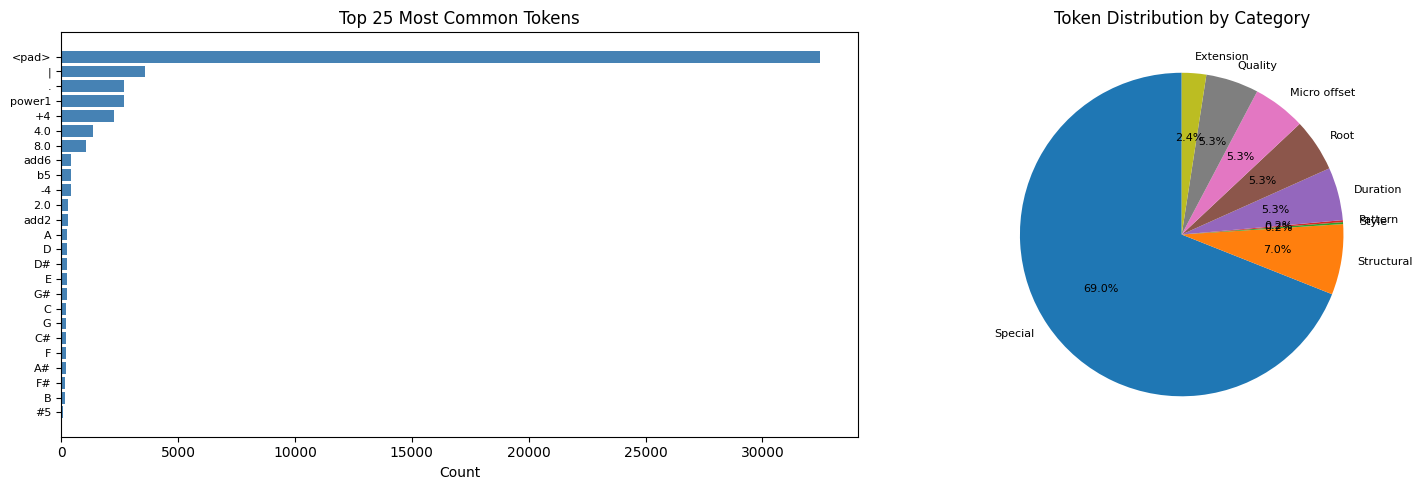

In [9]:
# Analyze vocabulary composition
print("Vocabulary by category:\n")

categories = {
    'Special': tokenizer.SPECIAL_TOKENS,
    'Structural': tokenizer.STRUCTURAL_TOKENS,
    'Style': tokenizer.STYLE_TOKENS,
    'Pattern': [tokenizer.PATTERN_TOKEN] + PATTERNS,
    'Duration': tokenizer.DURATION_TOKENS,
    'Root': tokenizer.ROOT_TOKENS,
    'Micro offset': tokenizer.MICRO_TOKENS,
    'Quality': tokenizer.QUALITY_TOKENS,
    'Extension': tokenizer.EXTENSION_TOKENS,
}

categorized = set()
for cat_name, cat_tokens in categories.items():
    in_vocab = [t for t in cat_tokens if t in vocab]
    not_in_vocab = [t for t in cat_tokens if t not in vocab]
    categorized.update(in_vocab)
    print(f"  {cat_name:>15}: {len(in_vocab):>3} in vocab, {len(not_in_vocab):>3} unused")
    if not_in_vocab and len(not_in_vocab) <= 5:
        print(f"                   unused: {not_in_vocab}")

uncategorized = [t for t in vocab if t not in categorized]
print(f"  {'Uncategorized':>15}: {len(uncategorized):>3} tokens")
if uncategorized:
    print(f"                   {uncategorized[:20]}")

# Visualize token frequency distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of top tokens
top_n = 25
top_tokens = counter.most_common(top_n)
top_labels = [t[0] for t in top_tokens]
top_counts = [t[1] for t in top_tokens]

axes[0].barh(range(top_n), top_counts[::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_labels[::-1], fontsize=8)
axes[0].set_xlabel('Count')
axes[0].set_title(f'Top {top_n} Most Common Tokens')

# Pie chart of token categories
cat_counts = {}
for cat_name, cat_tokens in categories.items():
    cat_count = sum(counter.get(t, 0) for t in cat_tokens)
    if cat_count > 0:
        cat_counts[cat_name] = cat_count

axes[1].pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Token Distribution by Category')

plt.tight_layout()
plt.show()


## 8. Dataset Packaging for GPT Training

Package the tokenized data into the format expected by the GPT model:
- `x`: input token indices `[:-1]` — shape `(N, block_size-1)`
- `y`: target token indices `[1:]` — shape `(N, block_size-1)`  
- `midi_data`: voicing arrays `[:-1]` — shape `(N, block_size-1, 16)`


In [ ]:
def package_dataset(all_tokens, all_voicings, token_to_idx, block_size=BLOCK_SIZE):
    """Package tokenized songs into training tensors.
    
    Returns:
        x: input indices (N, block_size-1)
        y: target indices (N, block_size-1) 
        midi_data: voicing arrays (N, block_size-1, voicing_dim)
    """
    N = len(all_tokens)
    seq_len = block_size - 1
    voicing_dim = all_voicings[0].shape[1] if len(all_voicings) > 0 else VOICING_DIM
    
    x = np.zeros((N, seq_len), dtype=np.int32)
    y = np.zeros((N, seq_len), dtype=np.int32)
    midi_data = np.zeros((N, seq_len, voicing_dim), dtype=np.float32)
    
    pad_idx = token_to_idx.get('<pad>', 0)
    
    for i in range(N):
        tokens = all_tokens[i]
        voicings = all_voicings[i]
        
        # Convert tokens to indices
        indices = [token_to_idx.get(t, pad_idx) for t in tokens]
        
        # x = indices[:-1], y = indices[1:]
        x[i] = indices[:seq_len]
        y[i] = indices[1:seq_len + 1]
        
        # midi_data = voicings[:-1]
        midi_data[i] = voicings[:seq_len]
    
    return x, y, midi_data

# Package the sample dataset
x, y, midi_data = package_dataset(all_tokens, all_voicings, tok2idx)

print(f"Dataset shapes:")
print(f"  x (input):     {x.shape}")
print(f"  y (target):    {y.shape}")
print(f"  midi_data:     {midi_data.shape}")
print(f"  Vocabulary:    {len(vocab)} tokens")
print(f"  Pad index:     {tok2idx.get('<pad>', 'N/A')}")

# Verify a sample
sample_idx = 0
print(f"\nSample song (idx={sample_idx}):")
non_pad_x = sum(1 for v in x[sample_idx] if v != tok2idx.get('<pad>', 0))
print(f"  Non-pad tokens: {non_pad_x}")
print(f"  First 20 input tokens:  {[idx2tok[i] for i in x[sample_idx, :20]]}")
print(f"  First 20 target tokens: {[idx2tok[i] for i in y[sample_idx, :20]]}")

# Check voicing at first chord
dot_positions = [j for j in range(len(x[sample_idx])) if idx2tok.get(x[sample_idx, j]) == '.']
if dot_positions:
    pos = dot_positions[0]
    v = midi_data[sample_idx, pos]
    notes_str = []
    for k in range(8):
        if v[k*2] > 0:
            notes_str.append(f"n={int(v[k*2])}+{v[k*2+1]:.2f}st")
    print(f"  First chord voicing (pos={pos}): [{', '.join(notes_str)}]")


## 9. Full Dataset Processing

Process all songs across all patterns to build the complete training dataset.

> ⚠️ **This cell processes ~240,000 MIDI files. Expect ~30-60 minutes.**  
> Run the sample cells above first to verify correctness.


In [ ]:
# FULL DATASET PROCESSING
# Uncomment to run (takes ~30-60 min for 240k files)

# print("Building FULL vocabulary...")
# vocab_full, tok2idx_full, idx2tok_full, all_tokens_full, all_voicings_full = build_vocabulary(
#     tokenizer, max_songs_per_pattern=None
# )
# 
# print(f"\nFull vocabulary size: {len(vocab_full)}")
# print(f"Total songs: {len(all_tokens_full)}")
# 
# # Package full dataset
# x_full, y_full, midi_full = package_dataset(
#     all_tokens_full, all_voicings_full, tok2idx_full
# )
# 
# print(f"\nFull dataset shapes:")
# print(f"  x: {x_full.shape}")
# print(f"  y: {y_full.shape}")
# print(f"  midi: {midi_full.shape}")
# 
# # Save to disk
# output_dir = Path('../dataset/tokenized_53tet')
# output_dir.mkdir(parents=True, exist_ok=True)
# 
# np.save(output_dir / 'x_train.npy', x_full)
# np.save(output_dir / 'y_train.npy', y_full)
# np.save(output_dir / 'midi_train.npy', midi_full)
# np.save(output_dir / 'vocabulary.npy', np.array(vocab_full))
# 
# with open(output_dir / 'token_to_idx.json', 'w') as f:
#     json.dump(tok2idx_full, f, indent=2)
# 
# print(f"\nSaved to {output_dir}")

print("Full processing cell ready (uncomment to run)")


## 10. Comparison: 12-TET vs 53-TET Tokenization

Side-by-side comparison showing how the same song is tokenized differently
in standard ChromaFlow vs our 53-TET extension.


In [ ]:
def compare_tokenizations(file_id='13651'):
    """Compare 12-TET and 53-TET tokenization of the same song."""
    
    # Find 12-TET file
    file_12 = next((f for f in MPE_DIR.glob('*.mid') 
                    if f.stem.split('_', 1)[0] == file_id), None)
    if not file_12:
        print(f"No 12-TET file found for ID {file_id}")
        return
    
    song_name = file_12.stem.split('_', 1)[1] if '_' in file_12.stem else file_12.stem
    print(f"Song: {song_name}")
    print("=" * 70)
    
    # Tokenize 12-TET (no pattern, no micro offsets)
    notes_12 = extract_mpe_notes(file_12)
    chords_12 = group_into_chords(notes_12)
    
    print(f"\n12-TET: {len(notes_12)} notes, {len(chords_12)} chords")
    print("First 5 chords (12-TET):")
    for i, chord in enumerate(chords_12[:5]):
        notes_str = [f"{note_name_from_midi(n['midi_note'])}" for n in chord]
        root_ref, intervals, _, _ = chord_to_53tet_intervals(chord)
        quality, _ = match_quality(intervals) if intervals else ('rest', [])
        print(f"  [{i}] {' '.join(notes_str):30s} -> {quality}")
    
    # Tokenize all 53-TET patterns
    for pattern in PATTERNS:
        rest = file_12.stem.split('_', 1)[1] if '_' in file_12.stem else ''
        fid = file_12.stem.split('_', 1)[0]
        expected = f"53TET_{fid}_{rest}.mid" if rest else f"53TET_{fid}.mid"
        f53 = MPE53_DIR / pattern / expected
        
        if not f53.exists():
            continue
        
        tokens_53, voicings_53 = tokenizer.tokenize_song(f53, pattern)
        non_pad = sum(1 for t in tokens_53 if t != '<pad>')
        dots = sum(1 for t in tokens_53 if t == '.')
        
        print(f"\n53-TET [{pattern}]: {non_pad} tokens, {dots} chords")
        
        # Show first 5 chords with micro offsets
        dot_positions = [j for j, t in enumerate(tokens_53) if t == '.'][:5]
        for di in dot_positions:
            # Get tokens until next dot or bar
            chord_toks = []
            for j in range(di, min(di + 8, len(tokens_53))):
                if j > di and tokens_53[j] in ('.', '|', '<end>'):
                    break
                chord_toks.append(tokens_53[j])
            
            # Get voicing
            v = voicings_53[di]
            notes_str = []
            for k in range(8):
                if v[k*2] > 0:
                    notes_str.append(note_name_from_midi(int(v[k*2]), v[k*2+1]))
            
            print(f"  {' '.join(chord_toks):40s} voicing: [{', '.join(notes_str)}]")

compare_tokenizations('13651')


## 11. Summary & Next Steps

### What this tokenizer provides:
1. **Token sequences** compatible with the ChromaFlow GPT architecture
2. **Extended voicing arrays** (16-dim) capturing microtonal pitch bends
3. **Pattern-aware** tokenization with `<pattern>` context token
4. **Microtonal offset tokens** (`+0` to `+4`) encoding 53-TET deviations

### Next Steps:
1. **Run full dataset processing** (Cell 9) to tokenize all 240k files
2. **Train/test split** — split by original song ID (keep all transpositions together)
3. **Model training** — adapt the GPT model with 16-dim MIDI embedding (vs 8-dim)
4. **Generation** — sample chord progressions with pattern conditioning
5. **Evaluation** — compare generated 53-TET progressions across patterns

### Model Architecture Changes (from ChromaFlow):
```python
# ChromaFlow:  midi_emb = Embedding(128, 4) → 8 notes × 4 = 32 → Linear(32, n_embd)
# ANIMA 53TET: midi_emb = Linear(16, n_embd)  # Direct projection of continuous voicing
```
The voicing array is now **continuous** (floats with pitch bends), not discrete
(integer MIDI notes), so we use a linear projection instead of an embedding lookup.
